# Lesson 3.8 — Physics-Informed Neural Networks (PINNs)

## The Bridge Between ML and CFD

Traditional CFD: discretize the PDE on a mesh → solve a large linear system.

PINNs (Raissi et al., 2019): use a neural network $\hat{u}(x, t; \theta)$ as the solution
approximation. Train the network to satisfy both the boundary conditions and the PDE
**residual** simultaneously.

The loss function is:

$$\mathcal{L}(\theta) = \lambda_{\text{pde}} \underbrace{\|\mathcal{R}[\hat{u}]\|^2}_{\text{PDE residual}} + \lambda_{\text{bc}} \underbrace{\|\hat{u} - u_{\text{bc}}\|^2}_{\text{BC loss}} + \lambda_{\text{data}} \underbrace{\|\hat{u} - u_{\text{data}}\|^2}_{\text{Data loss}}$$

Automatic differentiation (PyTorch/JAX) computes $\partial \hat{u}/\partial x$, $\partial^2 \hat{u}/\partial x^2$
exactly — no discretization error on the derivatives themselves.

---

## Advantages and Limitations

**Advantages**:
- Mesh-free: no mesh generation
- Handles inverse problems naturally (identify $\nu$ from velocity data)
- Sparse data fusion: incorporate sparse measurements into the solution
- Continuous representation: can query at any point

**Limitations**:
- Much slower than traditional CFD for forward problems
- Poor on sharp gradients / shocks (smooth network basis)
- Training convergence sensitive to loss weighting, learning rate, architecture
- No rigorous error bounds

PINNs are not replacing CFD — they are complementary, especially for inverse problems
and integrating experimental data with simulation.

---

## The PINN Recipe

1. Build a neural network $\hat{u}(x, t; \theta)$ (typically 4–8 layers, 20–100 neurons each).
2. Sample **collocation points** in the domain $(x_i, t_i)$.
3. Compute PDE residual at collocation points using auto-diff.
4. Compute BC/IC residual at boundary points.
5. Minimize combined loss using Adam or L-BFGS.

We'll demonstrate on the 1D Burgers' equation — without any time-stepping!


PINN Concept Demonstration

A PINN network NN(x,t) → u is trained to satisfy:
  1. PDE: ∂u/∂t + u*∂u/∂x = nu*∂²u/∂x²   (at collocation points)
  2. IC:  u(x, 0) = -sin(πx)               (at t=0 points)
  3. BC:  u(±1, t) = 0                      (at boundary points)

All three conditions enter the SINGLE loss function:
  L = λ_pde * ||PDE residual||² + λ_ic * ||IC error||² + λ_bc * ||BC error||²

Auto-differentiation gives ∂NN/∂x, ∂²NN/∂x², ∂NN/∂t exactly.
This is the key difference from traditional CFD (no spatial grid needed).


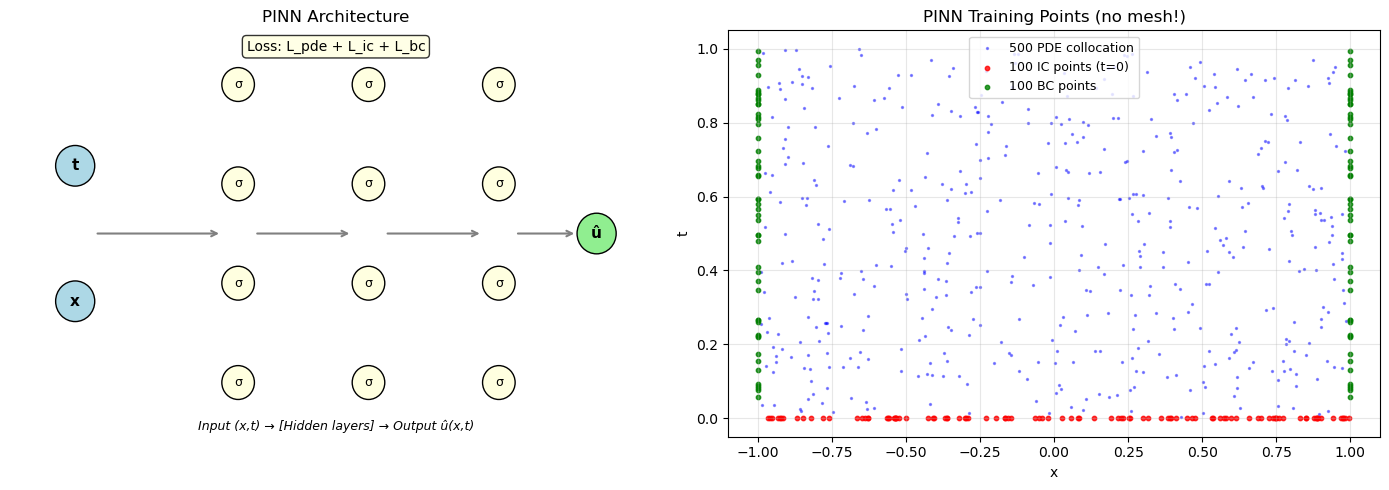

In [1]:
# PINN for 1D Burgers equation — using NumPy (no deep learning framework required)
# Solve: du/dt + u*du/dx = nu*d²u/dx² on [-1,1]×[0,1]
# IC: u(x,0) = -sin(pi*x)
# BC: u(-1,t) = u(1,t) = 0

# We'll use a simple 2-layer network and finite-difference gradient approximation
# to demonstrate the PINN concept without PyTorch.
# For a real PINN, you'd use PyTorch or JAX for auto-differentiation.

import numpy as np
import matplotlib.pyplot as plt

print("PINN Concept Demonstration")
print("="*50)
print("\nA PINN network NN(x,t) → u is trained to satisfy:")
print("  1. PDE: ∂u/∂t + u*∂u/∂x = nu*∂²u/∂x²   (at collocation points)")
print("  2. IC:  u(x, 0) = -sin(πx)               (at t=0 points)")
print("  3. BC:  u(±1, t) = 0                      (at boundary points)")
print("\nAll three conditions enter the SINGLE loss function:")
print("  L = λ_pde * ||PDE residual||² + λ_ic * ||IC error||² + λ_bc * ||BC error||²")
print("\nAuto-differentiation gives ∂NN/∂x, ∂²NN/∂x², ∂NN/∂t exactly.")
print("This is the key difference from traditional CFD (no spatial grid needed).")

# Plot the architecture concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PINN architecture diagram
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('PINN Architecture', fontsize=12)

# Input layer
for i, label in enumerate(['x', 't']):
    y = 2 + i*2
    ax.add_patch(plt.Circle((1, y), 0.3, color='lightblue', ec='black'))
    ax.text(1, y, label, ha='center', va='center', fontsize=11, fontweight='bold')

# Hidden layers
for layer_x, n_neurons in [(3.5, 4), (5.5, 4), (7.5, 4)]:
    ys = np.linspace(0.8, 5.2, n_neurons)
    for y in ys:
        ax.add_patch(plt.Circle((layer_x, y), 0.25, color='lightyellow', ec='black'))
        ax.text(layer_x, y, 'σ', ha='center', va='center', fontsize=9)

# Output
ax.add_patch(plt.Circle((9, 3), 0.3, color='lightgreen', ec='black'))
ax.text(9, 3, 'û', ha='center', va='center', fontsize=11, fontweight='bold')

# Connections (simplified)
for x1, x2 in [(1.3, 3.25), (3.75, 5.25), (5.75, 7.25), (7.75, 8.7)]:
    ax.annotate('', xy=(x2, 3), xytext=(x1, 3),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.text(5, 0.1, 'Input (x,t) → [Hidden layers] → Output û(x,t)',
        ha='center', fontsize=9, style='italic')

# Loss terms
ax.text(5, 5.7, 'Loss: L_pde + L_ic + L_bc', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Right: Collocation point sampling
np.random.seed(42)
# PDE collocation points
x_pde = np.random.uniform(-1, 1, 500)
t_pde = np.random.uniform(0, 1, 500)
# IC points
x_ic = np.random.uniform(-1, 1, 100)
t_ic = np.zeros(100)
# BC points
t_bc = np.random.uniform(0, 1, 50)

ax2 = axes[1]
ax2.scatter(x_pde, t_pde, s=2, c='blue', alpha=0.4, label=f'{len(x_pde)} PDE collocation')
ax2.scatter(x_ic, t_ic, s=10, c='red', alpha=0.8, label=f'{len(x_ic)} IC points (t=0)')
ax2.scatter([-1]*len(t_bc) + [1]*len(t_bc), np.concatenate([t_bc, t_bc]),
            s=10, c='green', alpha=0.8, label=f'{2*len(t_bc)} BC points')
ax2.set_xlabel('x'); ax2.set_ylabel('t')
ax2.set_title('PINN Training Points (no mesh!)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(-1.1, 1.1); ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

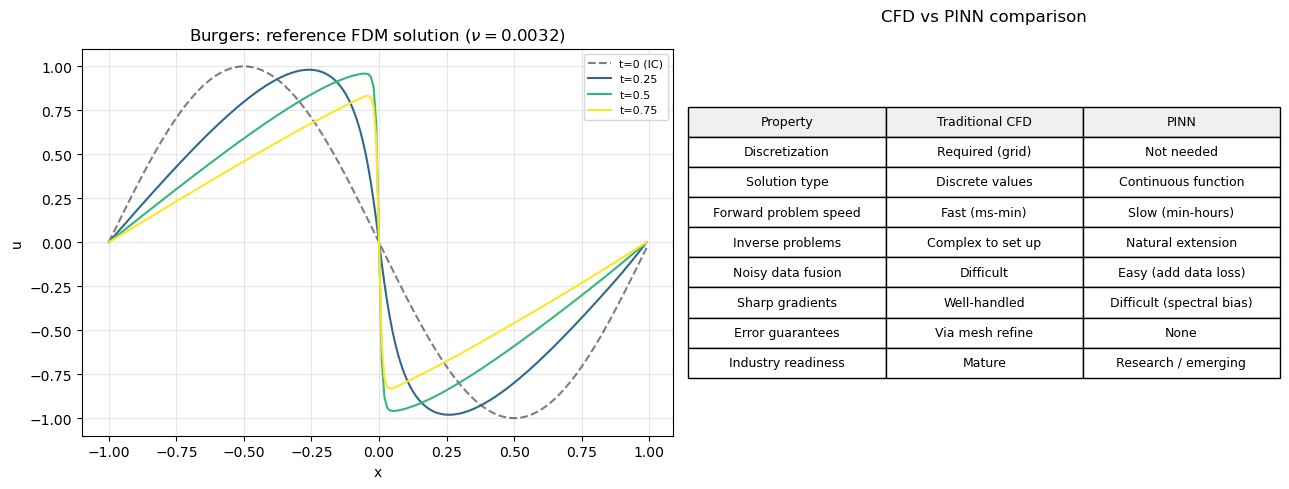

PINNs are best suited for: inverse problems, data assimilation,
multi-fidelity modeling, and parameter estimation — NOT replacing CFD.


In [2]:
# Compare PINN vs traditional CFD on Burgers equation
# Use traditional solver from Lesson 1.8 to show what PINN should recover

import numpy as np
import matplotlib.pyplot as plt

# Reference: traditional FDM solution of Burgers equation
nu   = 0.01 / np.pi
N    = 200
L    = 2.0  # domain [-1, 1]
dx   = L / N
x    = np.linspace(-1, 1, N, endpoint=False)
u    = -np.sin(np.pi * x)  # IC

dt = 0.0005
T  = 0.99
nt = int(T / dt)

snapshots = {}
for n in range(nt):
    u_old = u.copy()
    # Upwind advection
    u_plus  = np.roll(u_old, -1)
    u_minus = np.roll(u_old, 1)
    # Upwind based on sign of u
    adv = np.where(u_old > 0,
                   u_old*(u_old - u_minus)/dx,
                   u_old*(u_plus - u_old)/dx)
    visc = nu * (u_plus - 2*u_old + u_minus) / dx**2
    u = u_old - dt*adv + dt*visc
    u[0] = 0.0; u[-1] = 0.0  # Dirichlet BCs
    
    if n*dt in [0.25, 0.50, 0.75, 0.99]:
        snapshots[round(n*dt, 2)] = u.copy()
    if abs(n*dt - T) < dt/2:
        snapshots[T] = u.copy()

# Show the reference solution that a PINN would learn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Time evolution
times_to_plot = sorted(snapshots.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(times_to_plot) + 1))
axes[0].plot(x, -np.sin(np.pi*x), 'k--', linewidth=1.5, alpha=0.5, label='t=0 (IC)')
for t_plot, color in zip(times_to_plot, colors[1:]):
    if t_plot in snapshots:
        axes[0].plot(x, snapshots[t_plot], color=color, linewidth=1.5,
                     label=f't={t_plot}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u')
axes[0].set_title(f'Burgers: reference FDM solution ($\\nu={nu:.4f}$)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Comparison table
ax2 = axes[1]
ax2.axis('off')
table_data = [
    ['Property', 'Traditional CFD', 'PINN'],
    ['Discretization', 'Required (grid)', 'Not needed'],
    ['Solution type', 'Discrete values', 'Continuous function'],
    ['Forward problem speed', 'Fast (ms-min)', 'Slow (min-hours)'],
    ['Inverse problems', 'Complex to set up', 'Natural extension'],
    ['Noisy data fusion', 'Difficult', 'Easy (add data loss)'],
    ['Sharp gradients', 'Well-handled', 'Difficult (spectral bias)'],
    ['Error guarantees', 'Via mesh refine', 'None'],
    ['Industry readiness', 'Mature', 'Research / emerging'],
]

table = ax2.table(cellText=table_data[1:],
                  colLabels=table_data[0],
                  cellLoc='center',
                  loc='center',
                  colColours=['#f0f0f0']*3)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
ax2.set_title('CFD vs PINN comparison', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

print("PINNs are best suited for: inverse problems, data assimilation,")
print("multi-fidelity modeling, and parameter estimation — NOT replacing CFD.")

## Key Takeaways

- PINNs embed the PDE as a soft constraint in the neural network loss function.
- Automatic differentiation computes $\partial \hat{u}/\partial x$, $\partial \hat{u}/\partial t$ exactly — no mesh needed.
- Loss function combines PDE residual + BC/IC residual + optional data terms.
- **Strengths**: inverse problems, data fusion, mesh-free. **Weaknesses**: slow, poor near shocks.
- Neural operator methods (FNO, DeepONet) learn *solution operators* — faster inference for families of PDEs.
- The state of the art (2025): hybrid RANS-ML, differentiable CFD solvers, surrogate models for optimization.

---

**End of Module 3.** You now understand turbulence modeling, advanced schemes, and emerging ML methods.

**Next**: Module 4 — Projects: applying everything to real engineering problems.
